In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats
from tqdm import tqdm

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import itertools

In [22]:
try:
    from torch.nn.functional import scaled_dot_product_attention

    SDPA_AVAILABLE = True
except (ImportError, RuntimeError, OSError):
    scaled_dot_product_attention = None
    SDPA_AVAILABLE = False

In [23]:
train_adc_info = pd.read_csv('train_adc_info.csv',
                           index_col='planet_id')

In [24]:
def apply_linear_corr(linear_corr,clean_signal):
    linear_corr = np.flip(linear_corr, axis=0)
    for x, y in itertools.product(
                range(clean_signal.shape[1]), range(clean_signal.shape[2])
            ):
        poli = np.poly1d(linear_corr[:, x, y])
        clean_signal[:, x, y] = poli(clean_signal[:, x, y])
    return clean_signal

def clean_dark(signal, dead, dark, dt):
    dark = np.ma.masked_where(dead, dark)
    dark = np.tile(dark, (signal.shape[0], 1, 1))

    signal -= dark* dt[:, np.newaxis, np.newaxis]
    return signal

def preproc(dataset, adc_info, sensor, binning = 15):
    cut_inf, cut_sup = 39, 321
    sensor_sizes_dict = {"AIRS-CH0":[[11250, 32, 356], [1, 32, cut_sup-cut_inf]], "FGS1":[[135000, 32, 32], [1, 32, 32]]}
    binned_dict = {"AIRS-CH0":[11250 // binning // 2, 282], "FGS1":[135000 // binning // 2]}
    linear_corr_dict = {"AIRS-CH0":(6, 32, 356), "FGS1":(6, 32, 32)}
    planet_ids = adc_info.index
    
    feats = []
    for i, planet_id in tqdm(list(enumerate(planet_ids))):
        signal = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/{planet_id}/{sensor}_signal.parquet').to_numpy()
        dark_frame = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/' + str(planet_id) + '/' + sensor + '_calibration/dark.parquet', engine='pyarrow').to_numpy()
        dead_frame = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/' + str(planet_id) + '/' + sensor + '_calibration/dead.parquet', engine='pyarrow').to_numpy()
        flat_frame = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/' + str(planet_id) + '/' + sensor + '_calibration/flat.parquet', engine='pyarrow').to_numpy()
        linear_corr = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/' + str(planet_id) + '/' + sensor + '_calibration/linear_corr.parquet').values.astype(np.float64).reshape(linear_corr_dict[sensor])

        signal = signal.reshape(sensor_sizes_dict[sensor][0]) 
        gain = adc_info[f'{sensor}_adc_gain'].values[i]
        offset = adc_info[f'{sensor}_adc_offset'].values[i]
        signal = signal / gain + offset
        
        if sensor != "FGS1":
            signal = signal[:, :, cut_inf:cut_sup] #11250 * 32 * 282
            dt = axis_info['AIRS-CH0-integration_time'].dropna().values
            linear_corr = linear_corr[:, :, cut_inf:cut_sup]
            dark_frame = dark_frame[:, cut_inf:cut_sup]
            dead_frame = dead_frame[:, cut_inf:cut_sup]
            flat_frame = flat_frame[:, cut_inf:cut_sup]
        else:
            dt = np.ones(len(signal))*0.1 
            
        linear_corr_signal = apply_linear_corr(linear_corr, signal)
        signal = clean_dark(signal, dark_frame, dark_frame, dt)
        
        flat = flat_frame.reshape(sensor_sizes_dict[sensor][1])
        flat[dead_frame.reshape(sensor_sizes_dict[sensor][1])] = np.nan
        signal = signal / flat
        
        if sensor == "FGS1":
            signal = signal.reshape((sensor_sizes_dict[sensor][0][0], sensor_sizes_dict[sensor][0][1]*sensor_sizes_dict[sensor][0][2]))
        
        mean_signal = np.nanmean(signal, axis=1) # mean over the 32*32(FGS1) or 32(CH0) pixels
        cds_signal = (mean_signal[1::2] - mean_signal[0::2])
        binned = np.zeros((binned_dict[sensor]))
        for j in range(cds_signal.shape[0] // binning):
            binned[j] = cds_signal[j*binning:j*binning+binning].mean(axis=0)
                   
        if sensor == "FGS1":
            binned = binned.reshape((binned.shape[0],1))
            
        feats.append(binned)
        
    return np.stack(feats)
    
pre_train = np.concatenate([preproc('train', train_adc_info, "FGS1", 15*12), preproc('train', train_adc_info, "AIRS-CH0", 15)], axis=2)

In [25]:
# np.save("data_pretrain.npy", pre_train)

In [26]:
# pre_train.shape

In [27]:
# np.save('/kaggle/working/' + 'data_pretrain_clean.npy', pre_train)

In [28]:
# def phase_detector(signal):
#     phase1, phase2 = None, None
#     best_drop = 0
#     for i in range(50,150):        
#         t1 = signal[i:i+20].max() - signal[i:i+20].min()
#         if t1 > best_drop:
#             phase1 = i+20+5
#             best_drop = t1
    
#     best_drop = 0
#     for i in range(200,300):
#         t1 = signal[i:i+20].max() - signal[i:i+20].min()
#         if t1 > best_drop:
#             phase2 = i-5
#             best_drop = t1
    
#     return phase1, phase2

# train = pre_train.copy()
# for i in range(len(train_adc_info)):
    
#     p1,p2 = phase_detector(pre_train[i,:,1:].mean(axis=1))
#     train[i] = (train[i] - pre_train[i,p1:p2].mean(axis=0)) / pre_train[i,list(range(p1-40)) + list(range(p2+40,375))].mean(axis=0) * 1000.0

In [29]:
# np.save('/kaggle/working/' + 'data_train_clean.npy', train)

In [30]:
# pre_train[i,:,1:].mean(axis=1).shapex

In [31]:
# pre_train.shape

In [32]:
train = np.load('data_train_clean.npy')

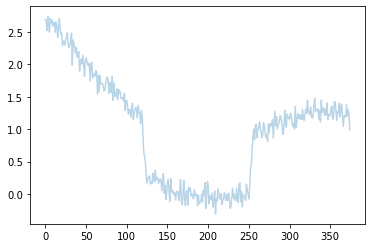

In [34]:
light_curve = train[0].sum(axis=1)
plt.plot(light_curve/light_curve.mean(), '-', alpha=0.3)

In [35]:
train_adc_info.index

Int64Index([    785834,   14485303,   17002355,   24135240,   25070640,
              26372015,   29348276,   33548644,   50637799,   53735941,
            ...
            4205863992, 4228013544, 4246618328, 4247255382, 4247918843,
            4249337798, 4257395405, 4266129805, 4273166473, 4286133832],
           dtype='int64', name='planet_id', length=673)

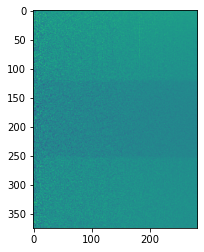

In [36]:
plt.imshow(train[0])

In [37]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os

class CustomDataset(Dataset):
    def __init__(self, data_train, indices, path_labels):
        """
        Args:
            data_train (np.array): Array of shape (673, 187, 282, 32).
            indices (np.array): Array of indices corresponding to the rows in df_labels.
            path_labels (str): Path to the CSV file containing labels.
        """
        self.data_train = torch.tensor(data_train)  # Convert the data to a tensor
        self.data_indices = torch.tensor(indices).long()  # Convert indices to tensor
        self.df_labels = pd.read_csv(path_labels)  # Load df_labels as a pandas DataFrame
        
    def __len__(self):
        # Return the total number of samples
        return len(self.data_indices)

    def __getitem__(self, idx):
        # Get the index from data_indices
        index = self.data_indices[idx].item()  # Convert tensor to Python scalar
        
        # Select the data_train sample corresponding to the index
        data_sample = self.data_train[idx]  # Directly access the data without cloning

        # Select the corresponding label row where the first column matches the index
        label_row = self.df_labels[self.df_labels.iloc[:, 0] == index].iloc[0].values[1:]  # Exclude the first column (index)

        # Convert label_row to a tensor
        label = torch.tensor(label_row).float()

        return data_sample, label

# Example usage
path_ground = 'train_labels.csv'

# Assuming 'train' and 'train_adc_info' are pre-loaded variables containing the training data and indices.
# For example, train could be an array of shape (673, 187, 282, 32), and train_adc_info.index gives the indices.
custom_dataset = CustomDataset(train, train_adc_info.index, path_ground)

# Create a DataLoader to iterate over the dataset
dataloader = DataLoader(custom_dataset, batch_size=32, shuffle=True)  # Pass 'custom_dataset' here

# Iterate through the dataset
for batch_data, batch_labels in dataloader:
    print("Batch Data Shape:", batch_data.shape)  # Should be (batch_size, 187, 282, 32)
    print("Batch Labels Shape:", batch_labels.shape)  # Should be (batch_size, 283)
    break


Batch Data Shape: torch.Size([32, 375, 283])
Batch Labels Shape: torch.Size([32, 283])


In [38]:
import torchvision.models as models

In [39]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class SpectralConv(nn.Module):
#     def __init__(self):
#         super(SpectralConv, self).__init__()
        
#         self.model = models.resnet50(pretrained=True)
#         self.model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
#         self.model.fc = nn.Linear(in_features=2048, out_features=283*2, bias=True)

    
#     def forward(self, x):
#         # Apply convolutional layer
#         x = self.model(x)
        
#         # Apply a Sigmoid activation after conv1
#         x = torch.sigmoid(x)
        
#         return x

# # Example usage:
# model = SpectralConv()
# model


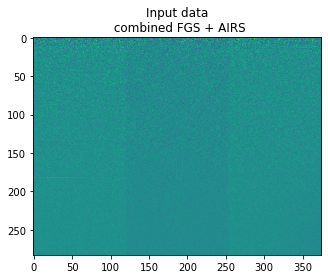

In [40]:
plt.imshow(batch_data[0,:,:].T)
plt.title('Input data\n combined FGS + AIRS')
plt.show()

/var/folders/dp/l6p51q511nbb1spwhbnzhnkc0000gs/T/ipykernel_51691/2867722626.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3641.)
  plt.plot(batch_labels[-1].T)


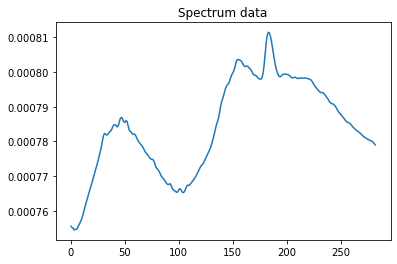

In [41]:
plt.plot(batch_labels[-1].T)
plt.title("Spectrum data")
plt.show()

In [80]:
args = {}

# Training params

args['batch_size'] = 32
args['test_batch_size'] = 10

args['epochs'] = 50*10*2
args['start_epoch'] = 0




# For optimizer
args['lr'] = 1e-7 # LR for B-SNN params
args['lr_decay'] = 1e-6
args['warmup_epochs'] = 10
args['lr_start'] = 1e-5


args['momentum'] = 0.5 # Required for SGD optimiser
args['weight_decay'] = 1e-4 # Weight-decay for ADAM-W optimiser



args['device'] =  torch.device('mps' if torch.backends.mps.is_available() else 'cpu')


In [81]:
import torch
import torch.nn as nn

class ParticipantVisibleError(Exception):
    pass

class ArielLoss(nn.Module):
    def __init__(self, naive_mean, naive_sigma, sigma_true):
        super(ArielLoss, self).__init__()
        self.naive_mean = naive_mean
        self.naive_sigma = naive_sigma
        self.sigma_true = sigma_true

    def forward(self, solution, submission):
        '''
        This is a Gaussian Log Likelihood based loss function. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
        we calculate the Gaussian Log-likelihood (GLL) value compared to the provided ground truth (x). We treat each pair of x_hat,
        x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
        the GLL value for one spectrum is the sum of all of them.

        Inputs:
            - solution: Ground Truth spectra (from test set)
                - shape: (nsamples, n_wavelengths)
            - submission: Predicted spectra and errors (from participants)
                - shape: (nsamples, n_wavelengths*2)
        '''
        if torch.any(submission < 0):
            raise ParticipantVisibleError('Negative values in the submission')

        n_wavelengths = 283

        # Predicted mean and standard deviation
        y_pred = submission[:, :n_wavelengths]
        # Set a non-zero minimum sigma pred to prevent division by zero errors
        sigma_pred = torch.clamp(submission[:, n_wavelengths:], min=1e-15)
        y_true = solution

        # Gaussian log-likelihood calculations
        GLL_pred = torch.sum(-0.5 * ((y_true - y_pred) / sigma_pred)**2 - torch.log(sigma_pred) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_true = torch.sum(-0.5 * ((y_true - y_true) / (self.sigma_true * torch.ones_like(y_true)))**2 - torch.log(self.sigma_true * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_mean = torch.sum(-0.5 * ((y_true - self.naive_mean * torch.ones_like(y_true)) / (self.naive_sigma * torch.ones_like(y_true)))**2 - torch.log(self.naive_sigma * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))

        # Score calculation
        submit_score = (GLL_pred - GLL_mean) / (GLL_true - GLL_mean)
        # submit_score = torch.clamp(submit_score, 0.0, 1.0)

        return -submit_score  # Return negative score as loss (since lower loss is better for training)


In [72]:
naive_mean = 0
naive_std = 0
count = 0

for train_batch_idx, (img, y_true) in enumerate(dataloader):

    naive_mean += y_true.mean()
    naive_std += y_true.std()

    count += 1

naive_mean /= count
naive_std /= count
print('Naive Mean: {}'.format(naive_mean))
print('Naive std: {}'.format(naive_std))
    

Naive Mean: 0.002505937358364463
Naive std: 0.0016123998211696744


In [45]:
import time
from torch import Tensor, nn
from typing import Dict, Iterable, Optional, Tuple

In [46]:
# class LayerNorm(nn.LayerNorm):
#     def forward(self, x: Tensor) -> Tensor:
#         return super().forward(x.float()).type(x.dtype)

    
    
# class Conv1d(nn.Conv1d):
#     def _conv_forward(
#         self, x: Tensor, weight: Tensor, bias: Optional[Tensor]
#     ) -> Tensor:
#         return super()._conv_forward(
#             x, weight.to(x.dtype), None if bias is None else bias.to(x.dtype)
#         )

    
# class Linear(nn.Linear):
#     def forward(self, x: Tensor) -> Tensor:
#         return F.linear(
#             x,
#             self.weight.to(x.dtype),
#             None if self.bias is None else self.bias.to(x.dtype),
#         )
    
# def sinusoids(length, channels, max_timescale=10000):
#     """Returns sinusoids for positional embedding"""
#     assert channels % 2 == 0
#     log_timescale_increment = np.log(max_timescale) / (channels // 2 - 1)
#     inv_timescales = torch.exp(-log_timescale_increment * torch.arange(channels // 2))
#     scaled_time = torch.arange(length)[:, np.newaxis] * inv_timescales[np.newaxis, :]
#     return torch.cat([torch.sin(scaled_time), torch.cos(scaled_time)], dim=1)


# class MultiHeadAttention(nn.Module):
#     use_sdpa = True

#     def __init__(self, n_state: int, n_head: int):
#         super().__init__()
#         self.n_head = n_head
#         self.query = Linear(n_state, n_state)
#         self.key = Linear(n_state, n_state, bias=False)
#         self.value = Linear(n_state, n_state)
#         self.out = Linear(n_state, n_state)

#     def forward(
#         self,
#         x: Tensor,
#         xa: Optional[Tensor] = None,
#         mask: Optional[Tensor] = None,
#         kv_cache: Optional[dict] = None,
#     ):
#         q = self.query(x)

#         if kv_cache is None or xa is None or self.key not in kv_cache:
#             # hooks, if installed (i.e. kv_cache is not None), will prepend the cached kv tensors;
#             # otherwise, perform key/value projections for self- or cross-attention as usual.
#             k = self.key(x if xa is None else xa)
#             v = self.value(x if xa is None else xa)
#         else:
#             # for cross-attention, calculate keys and values once and reuse in subsequent calls.
#             k = kv_cache[self.key]
#             v = kv_cache[self.value]

#         wv, qk = self.qkv_attention(q, k, v, mask)
#         return self.out(wv), qk

#     def qkv_attention(
#         self, q: Tensor, k: Tensor, v: Tensor, mask: Optional[Tensor] = None
#     ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
#         n_batch, n_ctx, n_state = q.shape
#         scale = (n_state // self.n_head) ** -0.25
#         q = q.view(*q.shape[:2], self.n_head, -1).permute(0, 2, 1, 3)
#         k = k.view(*k.shape[:2], self.n_head, -1).permute(0, 2, 1, 3)
#         v = v.view(*v.shape[:2], self.n_head, -1).permute(0, 2, 1, 3)

#         if SDPA_AVAILABLE and MultiHeadAttention.use_sdpa:
#             a = scaled_dot_product_attention(
#                 q, k, v, is_causal=mask is not None and n_ctx > 1
#             )
#             out = a.permute(0, 2, 1, 3).flatten(start_dim=2)
#             qk = None
#         else:
#             qk = (q * scale) @ (k * scale).transpose(-1, -2)
#             if mask is not None:
#                 qk = qk + mask[:n_ctx, :n_ctx]
#             qk = qk.float()

#             w = F.softmax(qk, dim=-1).to(q.dtype)
#             out = (w @ v).permute(0, 2, 1, 3).flatten(start_dim=2)
#             qk = qk.detach()

#         return out, qk


# class ResidualAttentionBlock(nn.Module):
#     def __init__(self, n_state: int, n_head: int, cross_attention: bool = False):
#         super().__init__()

#         self.attn = MultiHeadAttention(n_state, n_head)
#         self.attn_ln = LayerNorm(n_state)

#         self.cross_attn = (
#             MultiHeadAttention(n_state, n_head) if cross_attention else None
#         )
#         self.cross_attn_ln = LayerNorm(n_state) if cross_attention else None

#         n_mlp = n_state * 4
#         self.mlp = nn.Sequential(
#             Linear(n_state, n_mlp), nn.GELU(), Linear(n_mlp, n_state)
#         )
#         self.mlp_ln = LayerNorm(n_state)

#     def forward(
#         self,
#         x: Tensor,
#         xa: Optional[Tensor] = None,
#         mask: Optional[Tensor] = None,
#         kv_cache: Optional[dict] = None,
#     ):
#         x = x + self.attn(self.attn_ln(x), mask=mask, kv_cache=kv_cache)[0]
#         if self.cross_attn:
#             x = x + self.cross_attn(self.cross_attn_ln(x), xa, kv_cache=kv_cache)[0]
#         x = x + self.mlp(self.mlp_ln(x))
#         return x



In [47]:
# dims_tiny= {'n_mels':283, 'n_audio_ctx':188, 'n_audio_state':384, 'n_audio_head':6, 'n_audio_layer':int(4), 'n_vocab':51865, 'n_text_ctx':448, 'n_text_state':384, 'n_text_head':6, 'n_text_layer':int(4)}


In [48]:
# class AudioEncoder(nn.Module):
#     def __init__(
#         self, n_mels: int, n_ctx: int, n_state: int, n_head: int, n_layer: int
#     ):
#         super().__init__()
#         self.conv1 = Conv1d(n_mels, n_state, kernel_size=3, padding=1)
#         self.conv2 = Conv1d(n_state, n_state, kernel_size=3, stride=2, padding=1)
#         self.register_buffer("positional_embedding", 0*sinusoids(n_ctx, n_state))

#         self.blocks: Iterable[ResidualAttentionBlock] = nn.ModuleList(
#             [ResidualAttentionBlock(n_state, n_head) for _ in range(n_layer)]
#         )
#         self.ln_post = LayerNorm(n_state)

#     def forward(self, x: Tensor):
#         """
#         x : torch.Tensor, shape = (batch_size, n_mels, n_ctx)
#             the mel spectrogram of the audio
#         """
#         x = F.gelu(self.conv1(x))
        
#         x = F.gelu(self.conv2(x))
        
#         x = x.permute(0, 2, 1)
        
#         assert x.shape[1:] == self.positional_embedding.shape, "incorrect audio shape"
#         x = (x + self.positional_embedding).to(x.dtype)

#         for block in self.blocks:
#             x = block(x)

#         x = self.ln_post(x)
#         return x

In [49]:
# class SpectralDecoder(nn.Module):
#     def __init__(
#         self, n_ctx: int, n_dimout: int, n_state: int, n_head: int, n_layer: int
#     ):
#         super().__init__()

        
#         self.blocks: Iterable[ResidualAttentionBlock] = nn.ModuleList(
#             [
#                 ResidualAttentionBlock(n_state, n_head, cross_attention=True)
#                 for _ in range(n_layer)
#             ]
#         )
#         self.ln = LayerNorm(n_state)
#         self.fc_out = nn.Linear(n_ctx*n_state, n_dimout)
        
#         # mask = torch.empty(n_ctx, n_ctx).fill_(-np.inf).triu_(1)
#         # self.register_buffer("mask", mask, persistent=False)

#     def forward(self, x: Tensor, kv_cache: Optional[dict] = None):
#         """
#         x : torch.LongTensor, shape = (batch_size, <= n_ctx)
#             the text tokens
#         xa : torch.Tensor, shape = (batch_size, n_audio_ctx, n_audio_state)
#             the encoded audio features to be attended on
#         """
        
#         y = x.detach()
        
#         for block in self.blocks:
#             x = block(y, x, mask=None, kv_cache=kv_cache)

#         x = self.ln(x)
#         x = x.flatten(start_dim=1)
#         x = self.fc_out(x)
#         x = torch.sigmoid(x)
        
#         return x



In [50]:
# class SpectralTransformer(nn.Module):
#     def __init__(self, dims):
#         super().__init__()
#         self.dims = dims_tiny
#         self.encoder = AudioEncoder(
#             self.dims['n_mels'],
#             self.dims['n_audio_ctx'],
#             self.dims['n_audio_state'],
#             self.dims['n_audio_head'],
#             self.dims['n_audio_layer'],
#         )
#         self.decoder = SpectralDecoder(
#             self.dims['n_audio_ctx'],
#             283*2,
#             self.dims['n_text_state'],
#             self.dims['n_text_head'],
#             self.dims['n_text_layer'],
#         )


#     def forward(
#         self, x: torch.Tensor
#     ):
#         return self.decoder(self.encoder(x))


In [51]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torchvision import models

# class SpectralConv(nn.Module):
#     def __init__(self):
#         super(SpectralConv, self).__init__()
        
#         # Use EfficientNet (pretrained)
#         self.model = models.efficientnet_b0(pretrained=True)
        
#         # Adjust the first convolutional layer for 1-channel input instead of 3-channel RGB
#         self.model.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

#         # Adjust the final fully connected layer to the desired output size
#         self.model.classifier[1] = nn.Linear(in_features=1280, out_features=283*2, bias=True)

#     def forward(self, x):
#         # Apply convolutional layers and fully connected layers
#         x = self.model(x)
        
#         # Apply a Sigmoid activation after conv layers
#         x = torch.sigmoid(x)
        
#         return x

# # Example usage:
# model = SpectralConv()
# model


In [52]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torchvision import models

# class SpectralConv_efficient(nn.Module):
#     def __init__(self):
#         super(SpectralConv_efficient, self).__init__()
        
#         # Use EfficientNet (pretrained)
#         self.model = models.efficientnet_b0(pretrained=True)
        
#         # Adjust the first convolutional layer for 1-channel input instead of 3-channel RGB
#         self.model.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

#         # Adjust the final fully connected layer to the desired output size
#         self.model.classifier[1] = nn.Linear(in_features=1280, out_features=283*2, bias=True)

#     def forward(self, x):
#         # Apply convolutional layers and fully connected layers
#         x = self.model(x)
        
#         # Apply a Sigmoid activation after conv layers
#         x = torch.sigmoid(x)
        
#         return x


In [66]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class SpectralConv_oneD(nn.Module):
#     def __init__(self):
#         super(SpectralConv_oneD, self).__init__()
        
#         # First 1D convolutional layer for 1-channel input, mimicking EfficientNet's first conv layer
#         self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm1d(32)
        
#         # Additional 1D convolutional layers to mimic EfficientNet's depth and complexity
#         self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1, bias=False)
#         self.bn2 = nn.BatchNorm1d(64)
        
#         self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1, bias=False)
#         self.bn3 = nn.BatchNorm1d(128)
        
#         self.conv4 = nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1, bias=False)
#         self.bn4 = nn.BatchNorm1d(256)
        
#         self.conv5 = nn.Conv1d(256, 512, kernel_size=3, stride=2, padding=1, bias=False)
#         self.bn5 = nn.BatchNorm1d(512)
        
#         # Fully connected layer for final output to match [32, 566] (batch size, output size)
#         self.fc = nn.Linear(in_features=512 * 12, out_features=566, bias=True)

#     def forward(self, x):
#         # Pass input through convolutional layers with activation and batch normalization
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))
#         x = F.relu(self.bn3(self.conv3(x)))
#         x = F.relu(self.bn4(self.conv4(x)))
#         x = F.relu(self.bn5(self.conv5(x)))
        
#         # Flatten the output for the fully connected layer
#         x = x.view(x.size(0), -1)  # Flatten
#         x = self.fc(x)              # Fully connected layer
        
#         # Apply sigmoid activation
#         x = torch.sigmoid(x)
        
#         return x


In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class c3po(nn.Module):
    def __init__(self, input_shape):
        super(c3po, self).__init__()
        C_in, L_in = input_shape  # Channels and Length

        # First convolutional layer
        self.conv1 = nn.Conv1d(
            in_channels=C_in,
            out_channels=50,
            kernel_size=3,
            padding=1  # 'same' padding
        )
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        # Second convolutional layer
        self.conv2 = nn.Conv1d(
            in_channels=50,
            out_channels=25,
            kernel_size=2,
            padding=1  # 'same' padding
        )
        self.pool2 = nn.MaxPool1d(kernel_size=1)

        # Third convolutional layer
        self.conv3 = nn.Conv1d(
            in_channels=25,
            out_channels=25,
            kernel_size=1
        )

        # Calculate the size after convolution and pooling
        self.feature_dim = self._get_feature_dim(input_shape)

        # Fully connected layers
        self.fc1 = nn.Linear(self.feature_dim, 128)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(128, 566)  # Output size adjusted to match label size

    def _get_feature_dim(self, input_shape):
        # Create a dummy input to compute the output size after convolutions
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            feature_dim = dummy_output.view(-1).shape[0]
        return feature_dim

    def _forward_features(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.tanh(self.conv3(x))
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x


In [54]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class LocalFullyConnectedLayer(nn.Module):
#     def __init__(self, time_steps, num_wavelengths, local_layer_size, num_local_layers, translation_delta=0, pooling_type='max', dropout_rate=0):
#         """
#         Builds locally fully connected layers, with optional convolution followed by pooling.
#         """
#         super(LocalFullyConnectedLayer, self).__init__()
        
#         self.translation_delta = translation_delta
#         self.num_local_layers = num_local_layers
#         self.local_layer_size = local_layer_size
#         self.dropout_rate = dropout_rate
#         self.num_wavelengths = num_wavelengths
#         self.time_steps = time_steps
        
#         layers = []
        
#         # Optional wide convolution for translation invariance over time steps
#         if self.translation_delta > 0:
#             kernel_size = time_steps - 2 * translation_delta
#             self.conv = nn.Conv1d(
#                 in_channels=num_wavelengths,
#                 out_channels=local_layer_size,
#                 kernel_size=kernel_size,
#                 padding=0
#             )
#             if pooling_type == 'max':
#                 self.pooling = nn.AdaptiveMaxPool1d(1)
#             elif pooling_type == 'avg':
#                 self.pooling = nn.AdaptiveAvgPool1d(1)
#             else:
#                 raise ValueError(f"Unrecognized pooling_type: {pooling_type}")
            
#             input_size = local_layer_size  # Adjusted size after convolution and pooling
#         else:
#             self.conv = None
#             input_size = num_wavelengths * time_steps  # Flattened input size
        
#         # Fully connected layers
#         for i in range(num_local_layers):
#             layers.append(nn.Linear(input_size, local_layer_size))
#             layers.append(nn.ReLU())
#             if dropout_rate > 0:
#                 layers.append(nn.Dropout(dropout_rate))
#             input_size = local_layer_size  # For subsequent layers, input size is local_layer_size
        
#         self.fc_layers = nn.Sequential(*layers)
    
#     def forward(self, x):
#         # x shape: [batch_size, time_steps, num_wavelengths]
#         x = x.transpose(1, 2)  # Transpose to [batch_size, num_wavelengths, time_steps]
        
#         if self.conv:
#             x = F.relu(self.conv(x))  # Apply convolution
#             x = self.pooling(x).squeeze(2)  # Apply pooling and remove time dimension
#         else:
#             x = x.reshape(x.size(0), -1)  # Flatten input
        
#         x = self.fc_layers(x)
#         return x

# class AstroFCModel(nn.Module):
#     def __init__(self, time_steps, num_wavelengths, local_layer_params, final_output_size):
#         """
#         Model for classifying time series data with multiple wavelengths.
#         """
#         super(AstroFCModel, self).__init__()
        
#         # Local fully connected layer
#         self.local_fc = LocalFullyConnectedLayer(
#             time_steps=time_steps,
#             num_wavelengths=num_wavelengths,
#             local_layer_size=local_layer_params['local_layer_size'],
#             num_local_layers=local_layer_params['num_local_layers'],
#             translation_delta=local_layer_params['translation_delta'],
#             pooling_type=local_layer_params['pooling_type'],
#             dropout_rate=local_layer_params['dropout_rate']
#         )
        
#         # Final output layer
#         self.fc_final = nn.Linear(local_layer_params['local_layer_size'], final_output_size)
    
#     def forward(self, x):
#         # x shape: [batch_size, time_steps, num_wavelengths]
#         x = self.local_fc(x)
#         x = self.fc_final(x)
#         x = torch.sigmoid(x)
#         return x

# # Example usage:
# time_steps = 375
# num_wavelengths = 283
# local_layer_params = {
#     'local_layer_size': 128,   # Size of the local fully connected layers
#     'num_local_layers': 64,     # Number of local fully connected layers
#     'translation_delta': 0,    # No convolution
#     'pooling_type': 'max',     # Pooling type (not used when translation_delta=0)
#     'dropout_rate': 0.2        # Dropout rate
# }
# final_output_size = 566  # Desired output size


In [79]:
import torch
import torch.optim as optim



# Assuming SpectralTransformer and GLLLoss are already defined
specTrans = c3po([1, 375]) #AstroFCModel(time_steps, num_wavelengths, local_layer_params, final_output_size) #SpectralConv_efficient() #SpectralConv()
specTrans.to(args['device'])

# # Assuming SpectralTransformer and GLLLoss are already defined
# specTrans = SpectralTransformer(dims=dims_tiny)
# specTrans.to(args['device'])



# Optimizer with a smaller learning rate
optimizer = optim.Adam(specTrans.parameters(), lr=args['lr'], betas=(0.9, 0.999), eps=1e-08)

# Use the custom lr scheduler

# criterion =  nn.MSELoss()
# Use the custom lr scheduler

# Quantile loss for two quantiles: 0.1 and 0.9
# quantile_loss_fn = QuantileLoss(quantiles=[0.1, 0.9])

# Training loop
start_time = time.time()

loss_train_arr = []
loss_valid_arr = []

loss_min = np.inf
acc_max = -np.inf


for epoch in range(args['start_epoch'], args['epochs']):
    specTrans.train()

    # Calculate the current learning rate
    # current_lr = lrfn(epoch, num_warmup_steps=N_WARMUP_EPOCHS, lr_max=LR_MAX, num_cycles=0.50)
    #lrfn(current_step, num_warmup_steps, lr_max, num_cycles=0.50, num_training_steps=N_EPOCHS)

    train_acc = 0
    val_acc = 0
    loss_train = 0
    loss_valid = 0
    train_samples = 0
    val_samples = 0
    running_train_loss = 0
    running_eval_loss = 0


        
    for train_batch_idx, (img, y_true) in enumerate(dataloader):

        # Clear gradients for the optimizer before backward pass
        optimizer.zero_grad()
        
        

        img = img.to(torch.float32).to(args['device'])
        y_true = y_true.to(torch.float32).to(args['device'])

        img_permute = img.permute(0,2,1)
        img_unsqueeze = img.unsqueeze(1)
        light_curve = img_unsqueeze.sum(axis=3)/img_unsqueeze.mean()

        # Forward pass
        y_pred = specTrans(light_curve)
        # naive_mean = y_true.mean()
        # naive_std = y_true.std()
       
        train_loss_step = ArielLoss(naive_mean=naive_mean, naive_sigma=naive_std, sigma_true=1e-5)(        
            y_true,
            y_pred)
        
        # Compute loss
        # train_loss_step = quantile_loss_fn(outputs, y_true)

        # train_loss_step = torch.norm(y_true - y_pred, 1)/y_true.shape[0]#criterion(y_pred, y_true) #torch.norm(y_true - y_pred, 1)/y_true.shape[0]

        # Backward pass on the loss, not the score
        train_loss_step.backward()


        # Update the weights
        optimizer.step()
    
        print("Train loss: {}".format(float(train_loss_step)))

        # # If you want to accumulate training loss across the epoch
       
        lr_th_print = optimizer.param_groups[0]["lr"]
        print("LR: {:9f}".format(lr_th_print))

    # Print the accumulated loss per epoch (optional)
    print(f'Epoch {epoch} finished')

    if epoch % 20 == 0:

        chckpt_file_path = 'checkpoint_submission_astrocnn_{}.pth'.format(epoch)
        torch.save(specTrans.state_dict(), chckpt_file_path)

    # You can also save checkpoints and track validation loss/accuracy here if needed

end_time = time.time()
print('Total training time: {:.4f} seconds'.format(end_time - start_time))


Train loss: 0.9619340896606445
LR:  0.000010
Train loss: 1.058250069618225
LR:  0.000010
Train loss: 1.0001238584518433
LR:  0.000010
Train loss: 1.0475668907165527
LR:  0.000010
Train loss: 0.9785730242729187
LR:  0.000010
Train loss: 0.9808171987533569
LR:  0.000010
Train loss: 1.016676902770996
LR:  0.000010
Train loss: 1.0332870483398438
LR:  0.000010
Train loss: 0.99113929271698
LR:  0.000010
Train loss: 1.0034536123275757
LR:  0.000010
Train loss: 1.0010823011398315
LR:  0.000010
Train loss: 1.0292291641235352
LR:  0.000010
Train loss: 1.0842365026474
LR:  0.000010
Train loss: 0.8863252401351929
LR:  0.000010
Train loss: 1.0126206874847412
LR:  0.000010
Train loss: 0.9412509799003601
LR:  0.000010
Train loss: 1.0125712156295776
LR:  0.000010
Train loss: 0.967117190361023
LR:  0.000010
Train loss: 0.9955662488937378
LR:  0.000010
Train loss: 0.9758671522140503
LR:  0.000010
Train loss: 1.0283585786819458
LR:  0.000010
Train loss: 1.1660181283950806
LR:  0.000010
Epoch 0 finished
T

KeyboardInterrupt: 

In [68]:
light_curve.shape

torch.Size([1, 1, 375])

In [69]:
img_unsqueeze.shape

torch.Size([1, 1, 375, 283])

In [70]:
img.shape

torch.Size([1, 375, 283])